In [14]:
import os
import torch
import numpy as np
import random

def seed_everything(seed):
    """
    Set random seed for reproducibility
    """
    # 1. Python & Numpy
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    
    # 2. PyTorch (CPU & GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"🔒 Locked Random Seed: {seed}")


In [15]:



def seed_everything_random():
    """
    Tạo random seed, set seed đó, và return seed để bạn biết
    """
    # Tạo random seed
    random_seed = random.randint(0, 999999)
    
    # Set seed
    torch.manual_seed(random_seed)
    torch.cuda.manual_seed(random_seed)
    torch.cuda.manual_seed_all(random_seed)
    np.random.seed(random_seed)
    random.seed(random_seed)
    
    # Để reproducible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    return random_seed


In [16]:
#import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [17]:
#load data
df_men =pd.read_csv(r"/home/ducm/RERUM/dataset/Hillstrom-Men.csv")
df_men = df_men.drop(columns="Unnamed: 0")
print ("---------------------------")
print ("null count:")
print (df_men.isnull().sum())
print ("---------------------------")
print(df_men.dtypes)
print ("---------------------------")
print ("labels:")
print(df_men.columns.tolist())
print ("---------------------------")
print("data shape:")
print(df_men.shape)
print (df_men["spend"])

---------------------------
null count:
recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
visit              0
conversion         0
spend              0
treatment          0
dtype: int64
---------------------------
recency              int64
history_segment      int64
history            float64
mens                 int64
womens               int64
zip_code            object
newbie               int64
channel             object
visit                int64
conversion           int64
spend              float64
treatment            int64
dtype: object
---------------------------
labels:
['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'visit', 'conversion', 'spend', 'treatment']
---------------------------
data shape:
(42613, 12)
0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
42608    0.0
42609    0.0

In [18]:
#Hillstrom-men
#split num and cate
cate_cols = ['zip_code', 'channel']
num_cols = ['recency', 'history_segment', 'history']
#split x y t
y_men = df_men["spend"]
t_men = df_men["treatment"]
x_men = df_men.drop(columns=["spend", "treatment", "visit", "conversion"])

# x_men_encode = pd.get_dummies(x_men, columns=cate_cols, drop_first=True)
# x_men_encode = x_men_encode.astype(float)

#train test split - stratify CHỈ bằng treatment
x_men_train, x_men_test, t_men_train, t_men_test, y_men_train, y_men_test = train_test_split(
    x_men, t_men.values, y_men.values,
    test_size=0.3, random_state=42, stratify= t_men
)

# Tạo stratify cho val split - chỉ dùng treatment
stratify_var_train = pd.Series(t_men_train)

x_men_train, x_men_val, t_men_train, t_men_val, y_men_train, y_men_val = train_test_split(
    x_men_train, t_men_train, y_men_train,
    test_size=(1/7), random_state=42, stratify= t_men_train
)

# Fit get_dummies trên train, sau đó align với val/test
x_men_train_encode = pd.get_dummies(x_men_train, columns=cate_cols, drop_first=True)
x_men_val_encode = pd.get_dummies(x_men_val, columns=cate_cols, drop_first=True)
x_men_test_encode = pd.get_dummies(x_men_test, columns=cate_cols, drop_first=True)

# Align columns
x_men_val_encode = x_men_val_encode.reindex(columns=x_men_train_encode.columns, fill_value=0)
x_men_test_encode = x_men_test_encode.reindex(columns=x_men_train_encode.columns, fill_value=0)

scaler = StandardScaler()
x_men_train= scaler.fit_transform(x_men_train_encode)
x_men_val = scaler.transform(x_men_val_encode)
x_men_test = scaler.transform(x_men_test_encode)

print ("✅ Train/Val/Test split with stratification ONLY by treatment (NO DATA LEAKAGE)")
print (f"Train: {x_men_train.shape}, Val: {x_men_val.shape}, Test: {x_men_test.shape}")
print (f"Treatment distribution - Train: {np.mean(t_men_train):.2%}, Val: {np.mean(t_men_val):.2%}, Test: {np.mean(t_men_test):.2%}")
print (f"Spend mean - Train: {np.mean(y_men_train):.2f}, Val: {np.mean(y_men_val):.2f}, Test: {np.mean(y_men_test):.2f}")

# x_men = pd.DataFrame(x_men_train)
x_men_train

✅ Train/Val/Test split with stratification ONLY by treatment (NO DATA LEAKAGE)
Train: (25567, 10), Val: (4262, 10), Test: (12784, 10)
Treatment distribution - Train: 50.00%, Val: 50.00%, Test: 50.00%
Spend mean - Train: 1.00, Val: 0.95, Test: 1.14


array([[-1.36323828, -0.95770591, -0.65534372, ...,  1.22273126,
        -0.87900784,  1.12185957],
       [ 0.63260109, -0.30863193, -0.31367375, ...,  1.22273126,
        -0.87900784,  1.12185957],
       [ 0.34748118, -0.30863193, -0.4344948 , ...,  1.22273126,
         1.13764628, -0.89137716],
       ...,
       [ 0.34748118,  0.34044206,  0.30319097, ..., -0.8178412 ,
        -0.87900784,  1.12185957],
       [-1.07811837,  0.34044206,  0.16319135, ..., -0.8178412 ,
         1.13764628, -0.89137716],
       [-0.79299846, -0.95770591, -0.61911315, ..., -0.8178412 ,
        -0.87900784,  1.12185957]], shape=(25567, 10))

In [19]:
#Transform to tensor
def to_tensor(df):
    return torch.tensor(df, dtype=torch.float32)

x_men_train_t = to_tensor(x_men_train)
x_men_val_t = to_tensor(x_men_val)
x_men_test_t = to_tensor(x_men_test)

y_men_train_t = to_tensor(y_men_train).unsqueeze(1)
y_men_val_t = to_tensor(y_men_val).unsqueeze(1)
y_men_test_t = to_tensor(y_men_test).unsqueeze(1)

t_men_train_t = to_tensor(t_men_train.astype(float)).unsqueeze(1)
t_men_val_t = to_tensor(t_men_val.astype(float)).unsqueeze(1)
t_men_test_t = to_tensor(t_men_test.astype(float)).unsqueeze(1)

#Data loader
train_dataset = TensorDataset(x_men_train_t, t_men_train_t, y_men_train_t)
val_dataset = TensorDataset(x_men_val_t, t_men_val_t, y_men_val_t)
test_dataset = TensorDataset(x_men_test_t, t_men_test_t, y_men_test_t)

batch_size = 800
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

print ("-------------------------------------------------------------")
print ("✅Completed tranform to tensor✅")
print (f"Shape of train: x={x_men_train_t.shape}; y ={y_men_train_t.shape}; t={t_men_train_t.shape}")
print (f"Shape of val: x={x_men_val_t.shape}; y={y_men_val_t.shape}; t={t_men_val_t.shape}")
print (f"Shape of test: x={x_men_test_t.shape}; y={y_men_test_t.shape}; t={t_men_test_t.shape}")

-------------------------------------------------------------
✅Completed tranform to tensor✅
Shape of train: x=torch.Size([25567, 10]); y =torch.Size([25567, 1]); t=torch.Size([25567, 1])
Shape of val: x=torch.Size([4262, 10]); y=torch.Size([4262, 1]); t=torch.Size([4262, 1])
Shape of test: x=torch.Size([12784, 10]); y=torch.Size([12784, 1]); t=torch.Size([12784, 1])


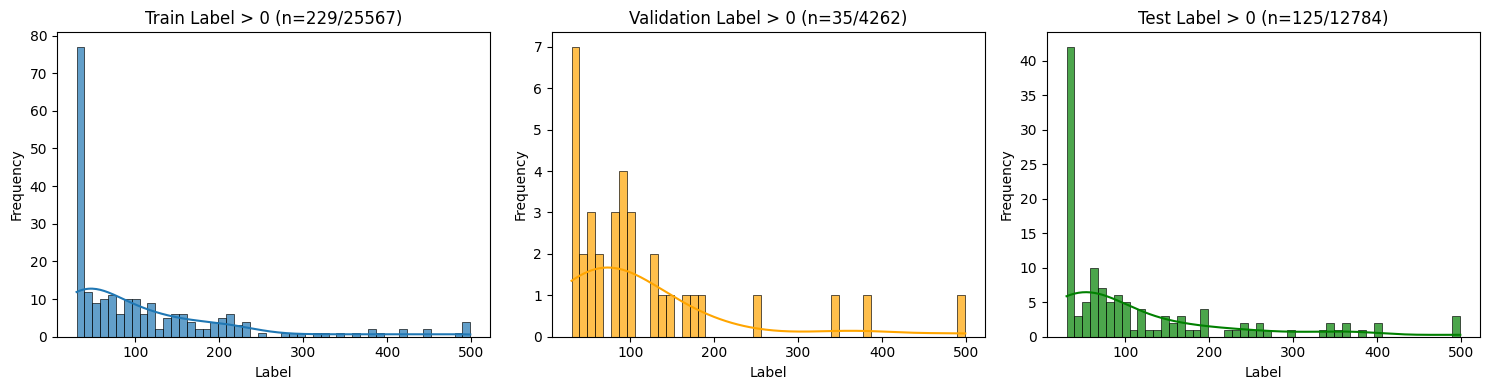

Train (>0) - Mean: 111.8092, Std: 106.8038, Min: 29.9900, Max: 499.0000
Val   (>0) - Mean: 116.0383, Std: 105.1155, Min: 29.9900, Max: 499.0000
Test  (>0) - Mean: 116.4350, Std: 113.1877, Min: 29.9900, Max: 499.0000


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter only values > 0
y_train_pos = y_men_train[y_men_train > 0]
y_val_pos = y_men_val[y_men_val > 0]
y_test_pos = y_men_test[y_men_test > 0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Train
sns.histplot(y_train_pos, bins=50, kde=True, ax=axes[0], alpha=0.7, edgecolor='black')
axes[0].set_title(f'Train Label > 0 (n={len(y_train_pos)}/{len(y_men_train)})')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Frequency')

# Validation
sns.histplot(y_val_pos, bins=50, kde=True, ax=axes[1], alpha=0.7, color='orange', edgecolor='black')
axes[1].set_title(f'Validation Label > 0 (n={len(y_val_pos)}/{len(y_men_val)})')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Frequency')

# Test
sns.histplot(y_test_pos, bins=50, kde=True, ax=axes[2], alpha=0.7, color='green', edgecolor='black')
axes[2].set_title(f'Test Label > 0 (n={len(y_test_pos)}/{len(y_men_test)})')
axes[2].set_xlabel('Label')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Train (>0) - Mean: {y_train_pos.mean():.4f}, Std: {y_train_pos.std():.4f}, Min: {y_train_pos.min():.4f}, Max: {y_train_pos.max():.4f}")
print(f"Val   (>0) - Mean: {y_val_pos.mean():.4f}, Std: {y_val_pos.std():.4f}, Min: {y_val_pos.min():.4f}, Max: {y_val_pos.max():.4f}")
print(f"Test  (>0) - Mean: {y_test_pos.mean():.4f}, Std: {y_test_pos.std():.4f}, Min: {y_test_pos.min():.4f}, Max: {y_test_pos.max():.4f}")

Evaluation metrics

In [21]:
from metrics import auuc, auqc, lift, krcc

Build Model

In [22]:
from tarnet import Tarnet

In [23]:
print("📊 Data Distribution Check:")
print(f"Y train: mean={y_men_train.mean():.4f}, std={y_men_train.std():.4f}")
print(f"Y train zeros: {(y_men_train == 0).sum()} / {len(y_men_train)} ({(y_men_train == 0).sum()/len(y_men_train)*100:.1f}%)")
print(f"\nTreatment balance:")
print(f"  Train: {(t_men_train == 1).sum()} treated, {(t_men_train == 0).sum()} control")
print(f"  Test:  {(t_men_test == 1).sum()} treated, {(t_men_test == 0).sum()} control")

📊 Data Distribution Check:
Y train: mean=1.0015, std=14.5993
Y train zeros: 25338 / 25567 (99.1%)

Treatment balance:
  Train: 12784 treated, 12783 control
  Test:  6392 treated, 6392 control


In [24]:
epochs = 300
lr = 0.001921959360402906
wd = 1e-4
early_stop_metric = "loss"
ema = True
ema_alpha = 0.15
patience = 15
shared_dropout = 0
outcome_droupout = 0 
shared_hidden = 200
outcome_hidden = 100
uplift_lambda = 46.463946182639155  
response_lambda = 0.001932820077085563
early_stop_start = 0
ranking_start = 15
print (f" uplift lambda = {uplift_lambda}")
print (f" response lambda = {response_lambda}")
print (f" early stop start = {early_stop_start}")
print (f" ranking start = {ranking_start}")
print (f" epochs = {epochs}")
print (f" learning rate = {lr}")
print (f" weight decay = {wd}")
print (f" early stop = {early_stop_metric}")
print (f" use ema = {ema}")
print (f" ema alpha = {ema_alpha}")
print (f" patience = {patience}")
print (f" share dropout = {shared_dropout}")
print (f" outcome dropout = {outcome_droupout}")
print (f" shared hidden = {shared_hidden}")
print (f" outcome hidden = {outcome_hidden}")


 uplift lambda = 46.463946182639155
 response lambda = 0.001932820077085563
 early stop start = 0
 ranking start = 15
 epochs = 300
 learning rate = 0.001921959360402906
 weight decay = 0.0001
 early stop = loss
 use ema = True
 ema alpha = 0.15
 patience = 15
 share dropout = 0
 outcome dropout = 0
 shared hidden = 200
 outcome hidden = 100


🔒 Locked Random Seed: 412312
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 300 epochs, select model with lowest validation loss
   Patience: 15 epochs
Epoch 1/300 | Base Loss: 250.8799 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 250.8799 | Val Loss: 376.0295 | Val Qini: -0.5576 ⭐ NEW BEST (lowest loss)
Epoch 2/300 | Base Loss: 121.4516 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 121.4516 | Val Loss: 377.7160 | Val Qini: -0.5585 (patience: 1/15)
Epoch 3/300 | Base Loss: 437.1790 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 437.1790 | Val Loss: 375.6994 | Val Qini: -1.0301 ⭐ NEW BEST (lowest loss)
Epoch 4/300 | Base Loss: 435.8513 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 435.8513 | Val Loss: 376.6804 | Val Qini: -0.5349 (patience: 1/15)
Epoch 5/300 | Base Loss: 146.2840 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 146.2840 | Val

/home/ducm/RERUM/Tarnet/tarnet.py:383: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


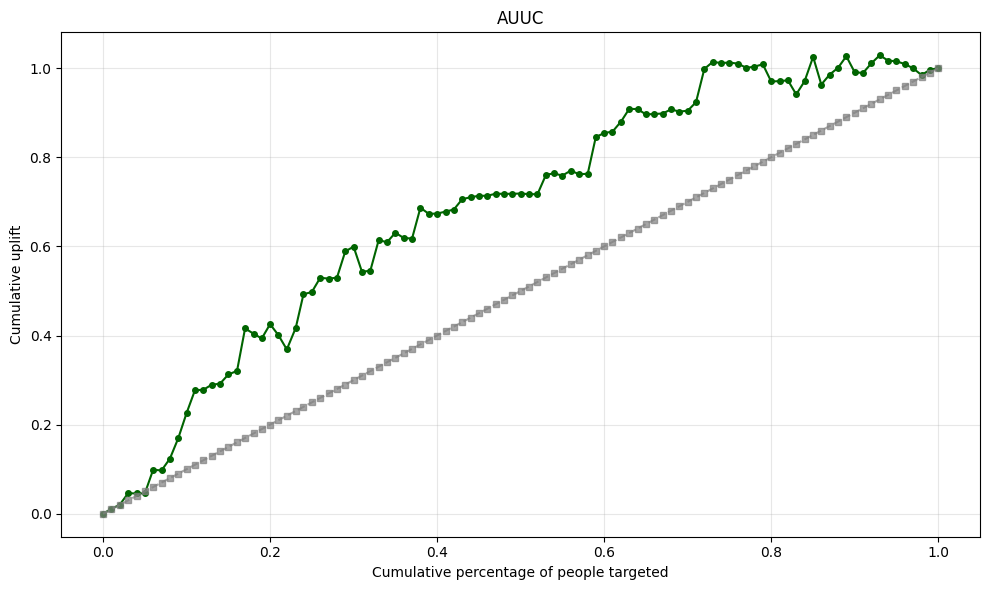

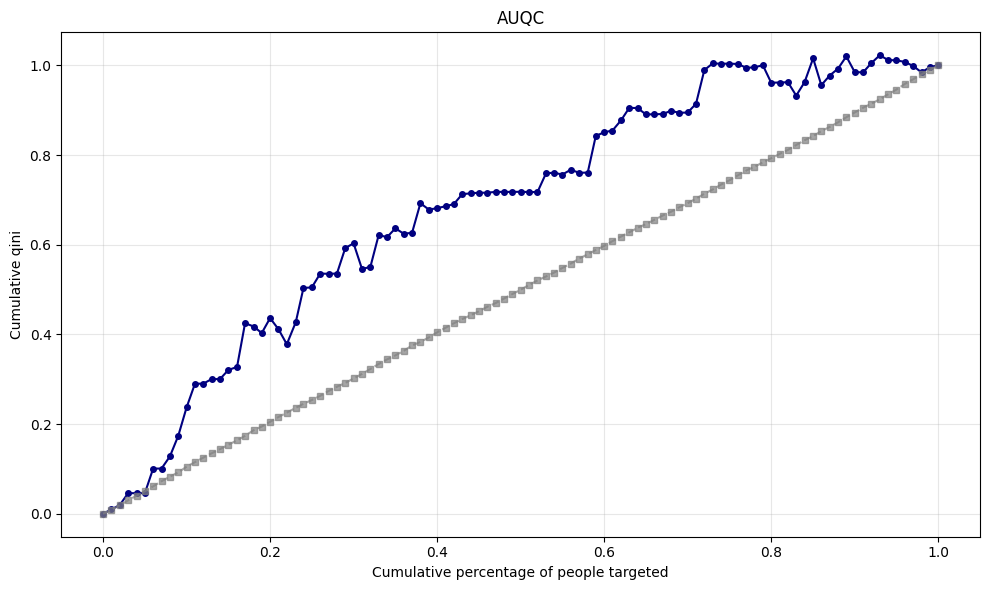

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.685
AUQC: 0.686
Lift: 2.051
KRCC: 0.147
ATE (predicted): 0.8140
ATE (true): 1.0265
ATE error: 0.2125


In [25]:
seed = 412312
seed_everything(seed)

tarnet = Tarnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      uplift_ranking=uplift_lambda,
                      response_ranking = response_lambda,
                      early_stop_start_epoch=early_stop_start,
                      ranking_start_epoch = ranking_start
)
tarnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred = tarnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

🔒 Locked Random Seed: 42
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 300 epochs, select model with lowest validation loss
   Patience: 15 epochs
Epoch 1/300 | Base Loss: 182.9313 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 182.9313 | Val Loss: 376.5581 | Val Qini: -0.6028 ⭐ NEW BEST (lowest loss)
Epoch 2/300 | Base Loss: 340.4286 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 340.4286 | Val Loss: 376.3193 | Val Qini: -1.1663 ⭐ NEW BEST (lowest loss)
Epoch 3/300 | Base Loss: 138.7776 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 138.7776 | Val Loss: 376.0860 | Val Qini: -1.3900 ⭐ NEW BEST (lowest loss)
Epoch 4/300 | Base Loss: 385.1835 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 385.1835 | Val Loss: 376.6972 | Val Qini: -0.9580 (patience: 1/15)
Epoch 5/300 | Base Loss: 561.0020 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 561.0020 |

/home/ducm/RERUM/Tarnet/tarnet.py:383: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


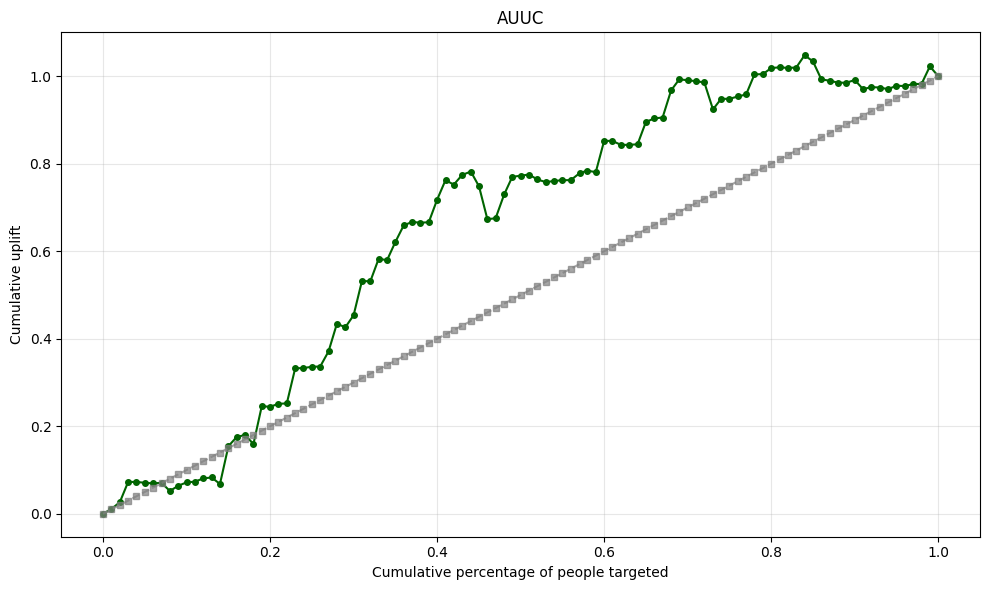

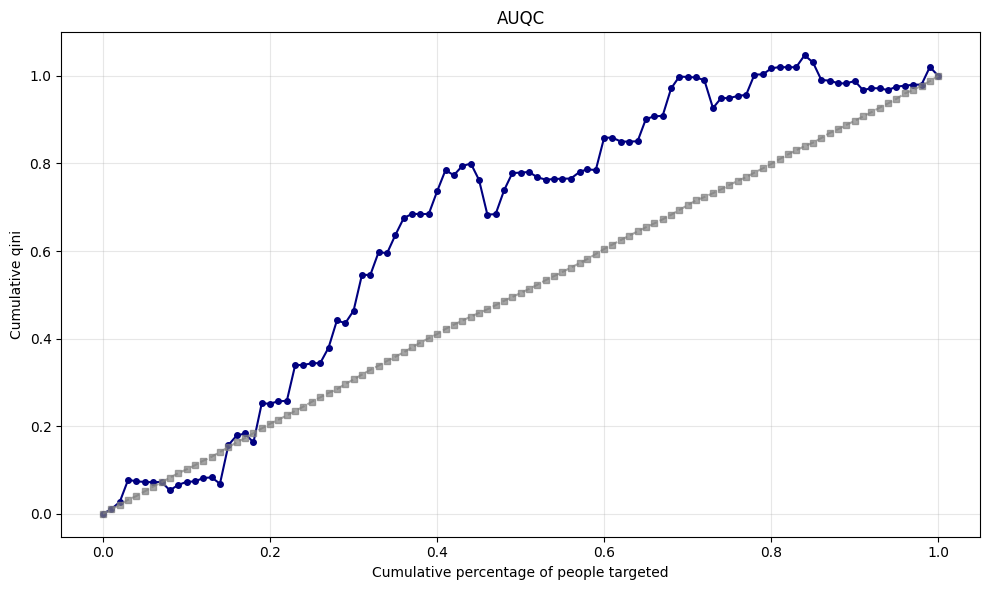

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.652
AUQC: 0.657
Lift: 1.551
KRCC: 0.122
ATE (predicted): 1.7887
ATE (true): 1.0265
ATE error: 0.7623


In [26]:
seed = 42
seed_everything(seed)

tarnet = Tarnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      uplift_ranking=uplift_lambda,
                      response_ranking = response_lambda,
                      early_stop_start_epoch=early_stop_start,
                      ranking_start_epoch = ranking_start
)
tarnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred = tarnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

🔒 Locked Random Seed: 1874
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 300 epochs, select model with lowest validation loss
   Patience: 15 epochs
Epoch 1/300 | Base Loss: 774.7004 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 774.7004 | Val Loss: 376.4366 | Val Qini: -0.0751 ⭐ NEW BEST (lowest loss)
Epoch 2/300 | Base Loss: 192.7103 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 192.7103 | Val Loss: 377.2717 | Val Qini: -0.7540 (patience: 1/15)
Epoch 3/300 | Base Loss: 623.6527 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 623.6527 | Val Loss: 376.0197 | Val Qini: -0.3826 ⭐ NEW BEST (lowest loss)
Epoch 4/300 | Base Loss: 294.5114 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 294.5114 | Val Loss: 376.8689 | Val Qini: -0.3076 (patience: 1/15)
Epoch 5/300 | Base Loss: 447.0639 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 447.0639 | Val L

/home/ducm/RERUM/Tarnet/tarnet.py:383: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


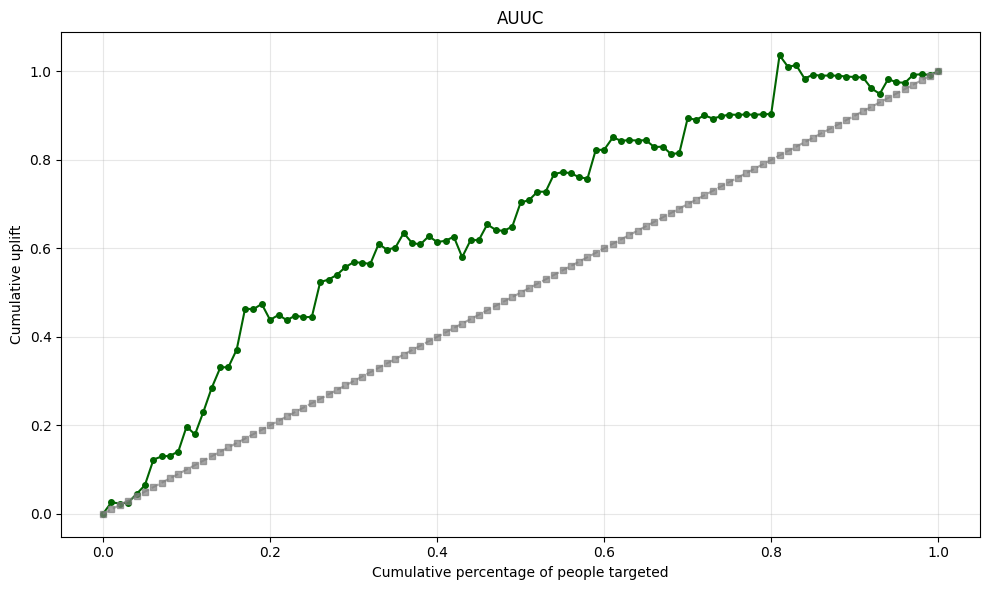

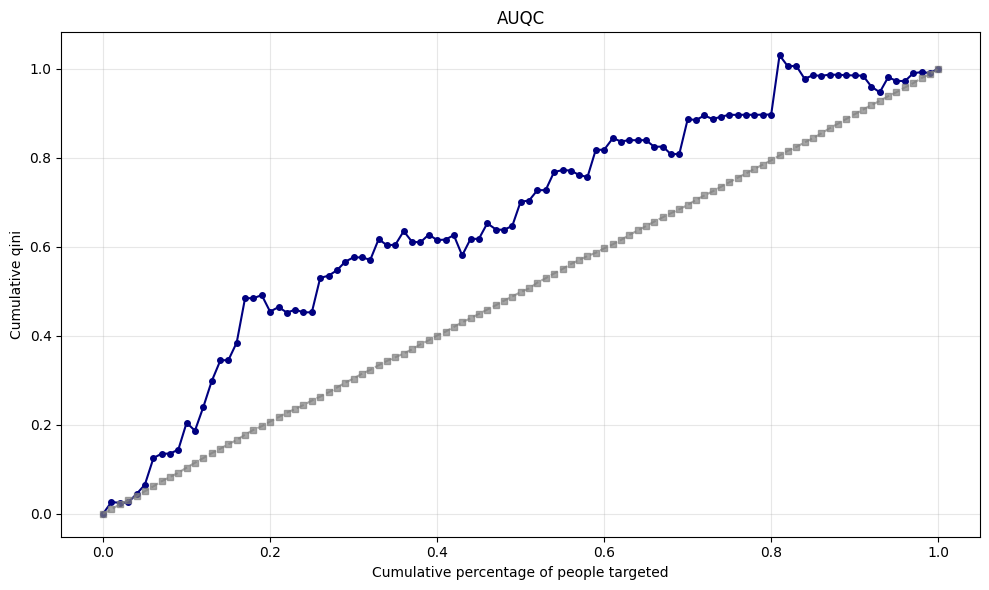

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.661
AUQC: 0.662
Lift: 1.946
KRCC: 0.162
ATE (predicted): -0.1663
ATE (true): 1.0265
ATE error: 1.1928


In [27]:
seed = 1874
seed_everything(seed)

tarnet = Tarnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      uplift_ranking=uplift_lambda,
                      response_ranking = response_lambda,
                      early_stop_start_epoch=early_stop_start,
                      ranking_start_epoch = ranking_start
)
tarnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred = tarnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

🔒 Locked Random Seed: 902745
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 300 epochs, select model with lowest validation loss
   Patience: 15 epochs
Epoch 1/300 | Base Loss: 542.2438 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 542.2438 | Val Loss: 376.6219 | Val Qini: -0.3186 ⭐ NEW BEST (lowest loss)
Epoch 2/300 | Base Loss: 156.0086 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 156.0086 | Val Loss: 376.2169 | Val Qini: -0.5187 ⭐ NEW BEST (lowest loss)
Epoch 3/300 | Base Loss: 674.0942 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 674.0942 | Val Loss: 376.9272 | Val Qini: -0.5456 (patience: 1/15)
Epoch 4/300 | Base Loss: 283.6537 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 283.6537 | Val Loss: 376.1446 | Val Qini: -0.4980 ⭐ NEW BEST (lowest loss)
Epoch 5/300 | Base Loss: 690.7025 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 690.70

/home/ducm/RERUM/Tarnet/tarnet.py:383: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


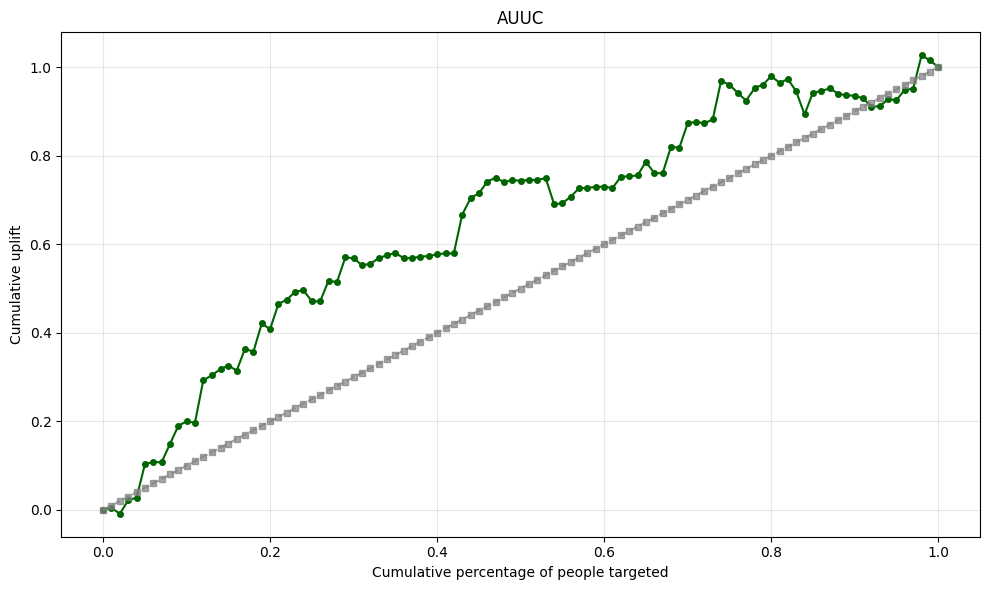

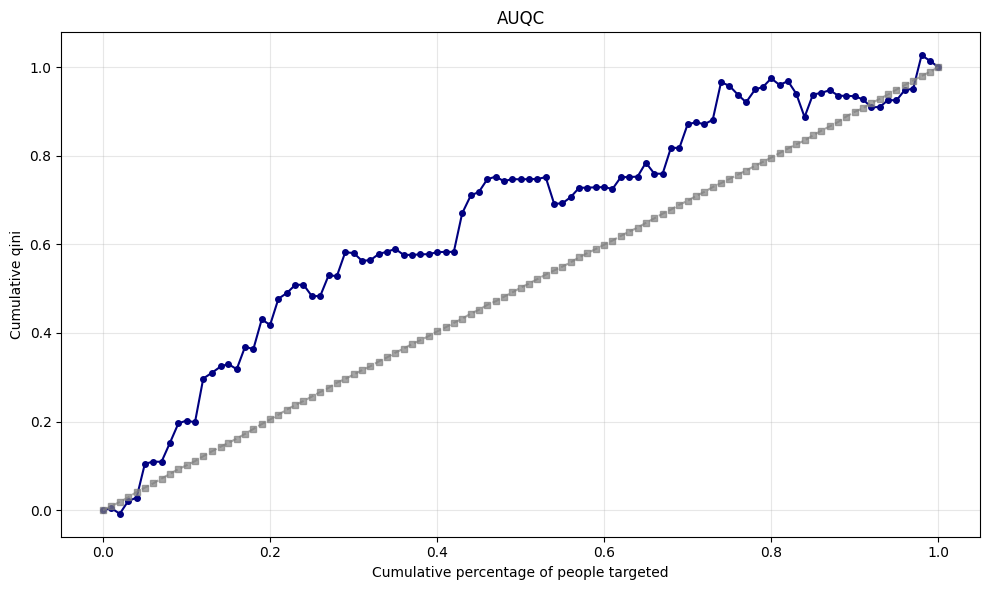

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.647
AUQC: 0.650
Lift: 1.943
KRCC: 0.145
ATE (predicted): -3.5146
ATE (true): 1.0265
ATE error: 4.5410


In [28]:
seed = 902745
seed_everything(seed)

tarnet = Tarnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      uplift_ranking=uplift_lambda,
                      response_ranking = response_lambda,
                      early_stop_start_epoch=early_stop_start,
                      ranking_start_epoch = ranking_start
)
tarnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred = tarnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

🔒 Locked Random Seed: 1
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 300 epochs, select model with lowest validation loss
   Patience: 15 epochs
Epoch 1/300 | Base Loss: 783.3855 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 783.3855 | Val Loss: 376.0400 | Val Qini: -1.4397 ⭐ NEW BEST (lowest loss)
Epoch 2/300 | Base Loss: 59.1327 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 59.1327 | Val Loss: 375.9641 | Val Qini: -0.9013 ⭐ NEW BEST (lowest loss)
Epoch 3/300 | Base Loss: 38.4640 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 38.4640 | Val Loss: 376.6590 | Val Qini: -0.6624 (patience: 1/15)
Epoch 4/300 | Base Loss: 816.2059 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 816.2059 | Val Loss: 377.8390 | Val Qini: -0.4473 (patience: 2/15)
Epoch 5/300 | Base Loss: 22.9178 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 22.9178 | Val Loss: 376.

/home/ducm/RERUM/Tarnet/tarnet.py:383: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


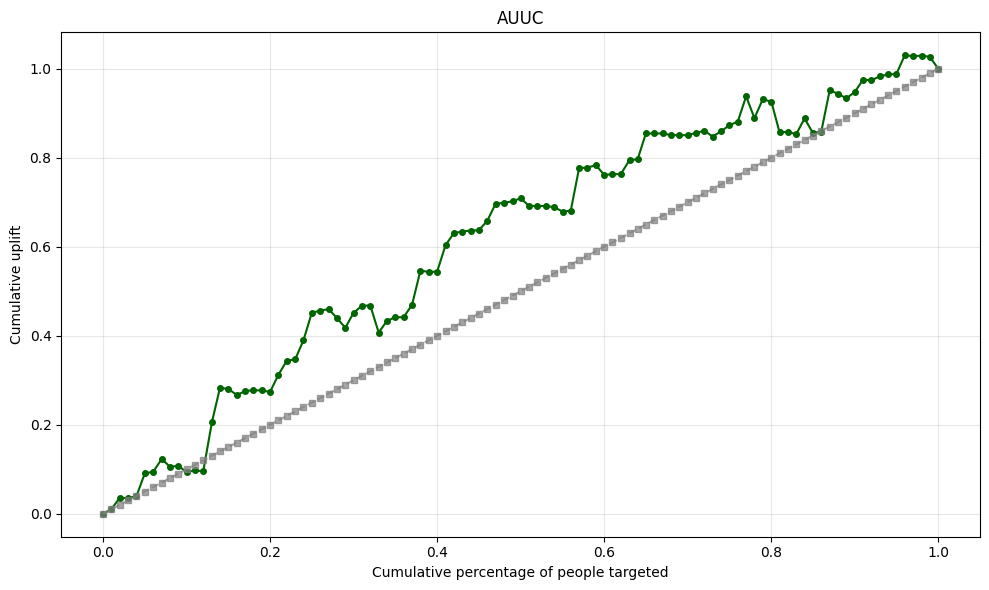

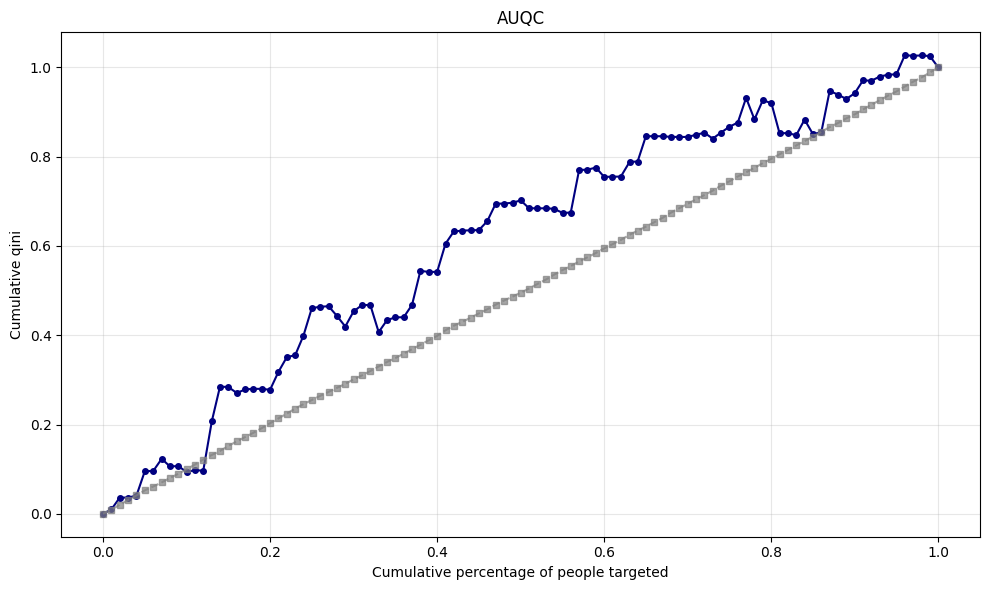

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.613
AUQC: 0.611
Lift: 1.546
KRCC: 0.093
ATE (predicted): -4.7725
ATE (true): 1.0265
ATE error: 5.7989


In [29]:
seed = 1
seed_everything(seed)

tarnet = Tarnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      uplift_ranking=uplift_lambda,
                      response_ranking = response_lambda,
                      early_stop_start_epoch= early_stop_start,
                      ranking_start_epoch = ranking_start
)
tarnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred = tarnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")